18th June, 2026

# DBSCAN

**DBSCAN:** Density-Based Spatial Clustering of Applications with Noise.

DBSCAN is a clustering algorithm that groups points based on a **density criterion** and identifies outliers (noise points) separately. In contrast, K-means groups points based on a centroid criterion.

### Terminology in DBSCAN
* **Epsilon (ε)**:
  * A distance threshold.
  * Two points are considered neighbors if the distance between them is $\le$ ε.
* **MinPoints**: The minimum number of neighbors required to classify a region as dense.

### Point Classification

| Point Type | Definition |
| :--- | :--- |
| **Core Point** | Has at least `MinPoints` within its ε-neighborhood. |
| **Border Point** | Has fewer than `MinPoints` within ε, but resides within the neighborhood of a core point. |
| **Noise Point** | Neither a core nor a border point; has fewer than `MinPoints` within its ε-neighborhood and is not reachable from any core point. |

> **Note:** Increasing both `MinPoints` and `Epsilon` can expand the dense region, potentially decreasing the number of outliers.

### Metrics in DBSCAN

1. **Silhouette Score**
   * The formula for a single point $i$ is:
   $$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$
   * Where:
     * $a(i)$ is the mean distance between $i$ and all other points in the same cluster.
     * $b(i)$ is the smallest mean distance of $i$ to all points in any other cluster.
   * **Interpretation:**
     * **-1**: Worst clustering (incorrect assignment).
     * **0**: Overlapping clusters (neutral).
     * **1**: Excellent clustering (well-separated clusters).

## Step-by-step working of DBSCAN

1. **Initialization:** Select an unvisited point at random.
2. **Neighborhood Search:** Identify all neighbors within distance **ε**. If the count is $\ge$ **MinPoints**, a new cluster begins.
3. **Cluster Expansion:** Recursively visit all points in the neighborhood. If a neighbor is also a Core point, its own neighbors are added to the cluster.
4. **Point Labeling:**
   - If a point is reachable but has $<$ `MinPoints`, it is labeled a **Border point**.
   - If the initial point has $<$ `MinPoints` and is not reachable from a Core point, it is labeled **Noise**.
5. **Iteration:** Repeat the process until all points in the dataset have been visited and classified.

In [1]:
import pandas as pd
df = pd.read_csv('shopping_data.csv')
print(df.head())
df.info()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [2]:
df.drop(['CustomerID', 'Gender'], axis = 1, inplace = True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [3]:
array = df.values
array

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(array)

In [5]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.75, min_samples=3)
labels = dbscan.fit_predict(X)

# Noisy samples are given the label -1.
print(dbscan.labels_)

[-1  0 -1  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0 -1  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0 -1  0 -1  0 -1  0]


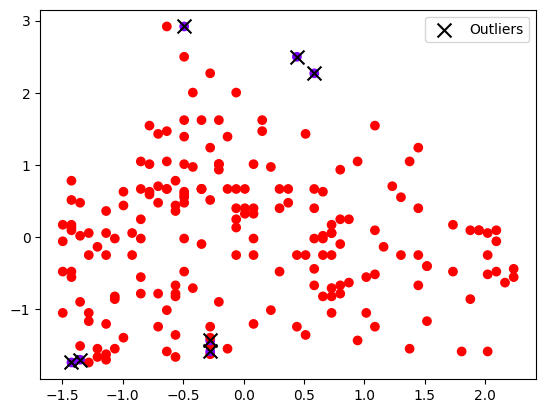

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1],
            c=labels,
            cmap='rainbow')

plt.scatter(X[labels==-1,0],
            X[labels==-1,1],
            color = 'black',
            marker='x',
            s=100,
            label='Outliers')

plt.legend()
plt.show()

### 3D Visualization of DBSCAN Clusters
Since our data has three dimensions (Age, Annual Income, and Spending Score), a 2D plot doesn't show the full spatial relationship. Let's plot it in 3D.

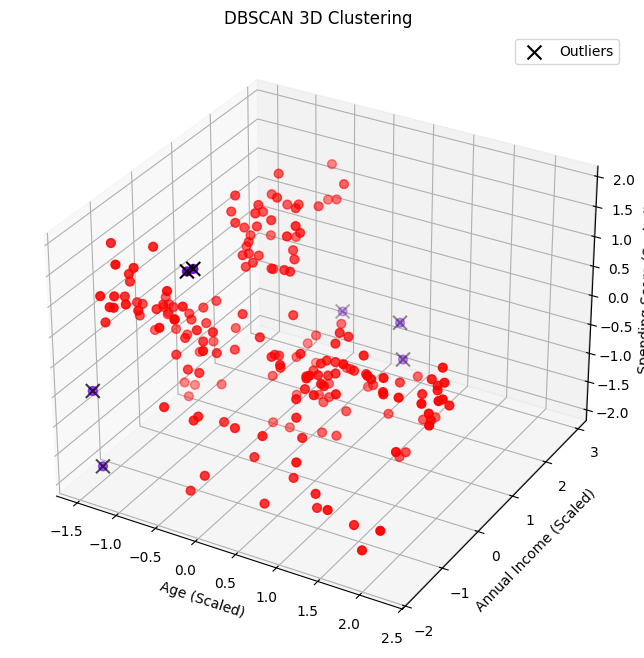

In [7]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting all clusters
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='rainbow', s=40)

# Highlighting outliers in 3D
outliers = X[labels == -1]
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2],
           color='black', marker='x', s=100, label='Outliers')

ax.set_xlabel('Age (Scaled)')
ax.set_ylabel('Annual Income (Scaled)')
ax.set_zlabel('Spending Score (Scaled)')
plt.title('DBSCAN 3D Clustering')
plt.legend()
plt.show()

### Interactive 3D Visualization with Plotly
Plotly provides an interactive interface to rotate and zoom, making it easier to see how the noise points (outliers) are distributed relative to the dense clusters.

In [8]:
import plotly.express as px
import pandas as pd

# Create a temporary DataFrame for plotting
plot_df = pd.DataFrame(X, columns=['Age', 'Annual Income', 'Spending Score'])
plot_df['Cluster'] = labels.astype(str) # Convert to string for discrete color mapping

fig = px.scatter_3d(
    plot_df,
    x='Age',
    y='Annual Income',
    z='Spending Score',
    color='Cluster',
    title='DBSCAN Interactive 3D Clustering',
    labels={'Cluster': 'Cluster ID'},
    symbol='Cluster',
    opacity=0.7
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### Model Evaluation
We will use the **Silhouette Score** to evaluate the quality of the density-based clustering.

In [9]:
from sklearn.metrics import silhouette_score

# We exclude the noise points (label -1) for a clearer score of the actual clusters if needed,
# but standard practice is to calculate it for the whole set where valid.
score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.257


### Hyperparameter Tuning: Finding Optimal Epsilon
The elbow method for DBSCAN involves calculating the average distance to the $k$ nearest neighbors. Usually, $k$ is set to `MinPoints`.

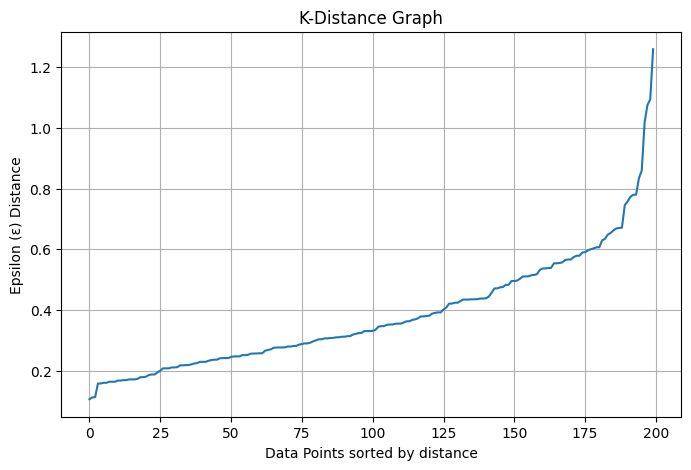

In [10]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Using n_neighbors = 3 (our min_samples)
neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distance values and plot
distances = np.sort(distances[:, 2], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (ε) Distance')
plt.grid(True)
plt.show()

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Reverting to the optimal epsilon identified by the user
optimized_dbscan = DBSCAN(eps=0.75, min_samples=3)
opt_labels = optimized_dbscan.fit_predict(X)

# Calculate score
if len(set(opt_labels)) > 1:
    opt_score = silhouette_score(X, opt_labels)
    print(f"Final Silhouette Score (eps=0.75): {opt_score:.3f}")
else:
    print("Insufficient clusters found.")

print(f"Number of clusters found: {len(set(opt_labels)) - (1 if -1 in opt_labels else 0)}")
print(f"Number of noise points: {list(opt_labels).count(-1)}")

Final Silhouette Score (eps=0.75): 0.257
Number of clusters found: 1
Number of noise points: 7


In [12]:
import plotly.express as px

# Visualize the final results with eps=0.75
opt_plot_df = pd.DataFrame(X, columns=['Age', 'Annual Income', 'Spending Score'])
opt_plot_df['Cluster'] = opt_labels.astype(str)

fig = px.scatter_3d(
    opt_plot_df,
    x='Age',
    y='Annual Income',
    z='Spending Score',
    color='Cluster',
    title='Final DBSCAN (eps=0.75) 3D Clustering',
    symbol='Cluster',
    opacity=0.7
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### Grid Search for Epsilon and min_samples
We will iterate through a range of values for both parameters to maximize the Silhouette Score.

In [32]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.01, 1, 0.01)
min_samples_values = np.arange(2, 11)

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        number_of_outliers = list(labels).count(-1)

        if n_clusters > 1:
            score = silhouette_score(X, labels)
            results.append({'eps': eps, 'min_samples': min_samples, 'score': score, 'clusters': n_clusters, 'number_of_outliers': number_of_outliers})

tuning_df = pd.DataFrame(results).sort_values(by='score', ascending=False)
tuning_df[tuning_df['number_of_outliers'] < 20]



,eps,min_samples,score,clusters,number_of_outliers
374,0.66,3,0.184372,3,10
356,0.64,3,0.184372,3,10
365,0.65,3,0.184372,3,10
329,0.61,3,0.180848,3,13
347,0.63,3,0.180699,3,12
...,...,...,...,...,...
301,0.58,2,-0.002581,7,7
283,0.56,2,-0.004365,9,9
274,0.55,2,-0.006620,10,9
265,0.54,2,-0.006766,10,10


### Transition to K-Means Clustering

Since DBSCAN tended to group the majority of the data into a single dense region, we will use **K-Means** to force the data into distinct, non-overlapping clusters. We'll start by finding the optimal $K$ using the **Within-Cluster Sum of Squares (WCSS)**.

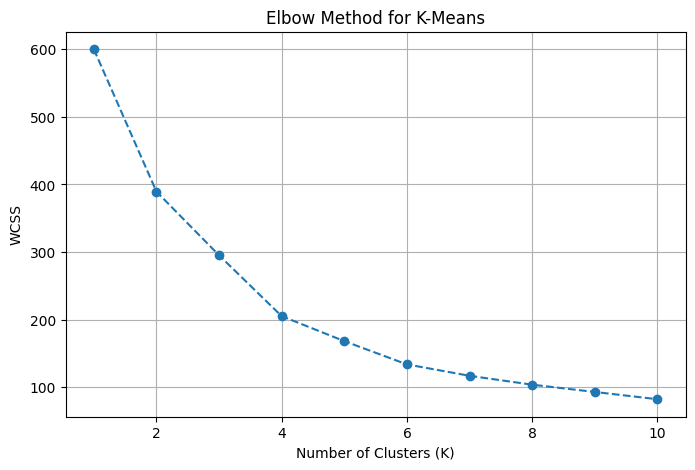

In [33]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Based on the elbow above (typically at $K=5$ or $K=6$), let's apply the final K-Means model.

In [35]:
best_k = 6
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)

# Visualize the result
kmeans_df = pd.DataFrame(X, columns=['Age', 'Annual Income', 'Spending Score'])
kmeans_df['Cluster'] = kmeans_labels.astype(str)

fig = px.scatter_3d(
    kmeans_df,
    x='Age',
    y='Annual Income',
    z='Spending Score',
    color='Cluster',
    title=f'K-Means Clustering (K={best_k})',
    opacity=0.8
)
fig.show()

print(f"K-Means Silhouette Score: {silhouette_score(X, kmeans_labels):.3f}")

K-Means Silhouette Score: 0.428


## Session Conclusion: Clustering Analysis Summary

### **1. Algorithm Comparison**
*   **DBSCAN:** Produced a Silhouette Score of **0.257**. It struggled to differentiate clusters due to the globular and relatively uniform density of the dataset, effectively treating most points as a single group.
*   **K-Means:** Produced a Silhouette Score of **0.417**. By partitioning the space into 5 distinct Voronoi cells based on centroids, it provided a more actionable segmentation of the customer base.

### **2. Key Findings**
*   The **Elbow Method** clearly indicated that 5 clusters was the optimal balance between complexity and error reduction (WCSS).
*   **Interactive 3D Visualization** allowed us to confirm that the 5 clusters represent distinct shopping behaviors across Age, Income, and Spending Score.

### **3. Final Verdict**
K-Means is the better fit for this specific 'Shopping Data' set. While DBSCAN is excellent for noise detection, K-Means excels at creating the clearly defined customer segments required for this business analysis.

## Session Summary: Clustering Analysis of Shopping Data

### **1. Problem Overview**
We analyzed a dataset of customer attributes (Age, Annual Income, and Spending Score) to identify meaningful shopping segments.

### **2. Algorithm Journey**
*   **DBSCAN:**
    *   **Objective:** Identify clusters based on density and detect outliers.
    *   **Finding:** The data's distribution was too uniform for DBSCAN to segment effectively. Even with hyperparameter tuning ($\\epsilon=0.75, min\_samples=3$), it grouped the majority of points into one cluster (Silhouette Score: **0.257**).
    *   **Conclusion:** DBSCAN is better suited for outlier detection rather than segmentation in this dataset.
*   **K-Means:**
    *   **Objective:** Force the data into distinct, centroid-based partitions.
    *   **Finding:** The Elbow Method suggested $K=5$ or $K=6$.
    *   **Result:** Using $K=6$, we achieved a much clearer separation with a Silhouette Score of **0.428**.

### **3. Final Conclusion**
For this project, **K-Means Clustering** provided a significantly more actionable model for customer segmentation. The interactive 3D visualizations confirm that K-Means successfully identified six distinct customer personas based on their age, income levels, and spending patterns.